# Inference — Fine-Grained Sans-Serif Font Recognition

Load the trained **EfficientNet-B2** checkpoint and classify new text images into one of **20 sans-serif font families**.

A **confidence threshold** rejects low-confidence predictions — if the image contains a font outside the 20 supported families, the model will output "Unrecognized font" instead of a forced (unreliable) classification.

In [1]:
import os
import json

import torch
import torch.nn as nn
import numpy as np
from PIL import Image
from torchvision import transforms, models
import matplotlib.pyplot as plt

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cpu


## 1 · Load Model & Metadata

Reconstruct the same EfficientNet-B2 architecture used during training and load the saved weights.

In [2]:
# Paths
MODEL_DIR = "../models"
CHECKPOINT_PATH = os.path.join(MODEL_DIR, "best_model.pth")
METADATA_PATH   = os.path.join(MODEL_DIR, "model_metadata.json")

# Load metadata
with open(METADATA_PATH, "r") as f:
    metadata = json.load(f)

CLASS_NAMES   = metadata["class_names"]
NUM_CLASSES   = metadata["num_classes"]
IMG_SIZE      = metadata["img_size"]
IMAGENET_MEAN = metadata["imagenet_mean"]
IMAGENET_STD  = metadata["imagenet_std"]

print(f"Model     : {metadata['architecture']}")
print(f"Classes   : {NUM_CLASSES}")
print(f"Input size: {IMG_SIZE}×{IMG_SIZE}")
print(f"Val acc   : {metadata['best_val_acc']:.4f}")
print(f"Fonts     : {', '.join(CLASS_NAMES)}")

# Rebuild architecture
def build_model(num_classes: int = NUM_CLASSES) -> nn.Module:
    model = models.efficientnet_b2(weights=None)
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3),
        nn.Linear(in_features, 512),
        nn.ReLU(inplace=True),
        nn.BatchNorm1d(512),
        nn.Dropout(p=0.2),
        nn.Linear(512, num_classes),
    )
    return model

# Load weights
model = build_model().to(DEVICE)
checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

total_params = sum(p.numel() for p in model.parameters())
print(f"\n✓ Model loaded — {total_params:,} parameters")

Model     : efficientnet_b2
Classes   : 20
Input size: 224×224
Val acc   : 0.9147
Fonts     : DMSans, Figtree, FiraSans, Heebo, Hind, Inter, Karla, Lato, Montserrat, Mulish, NotoSans, OpenSans, PTSans, Poppins, Raleway, Roboto, Rubik, SourceSans3, Ubuntu, WorkSans

✓ Model loaded — 8,433,686 parameters


## 2 · Inference Pipeline

**Smart crop:** When the input image is large (e.g. a full paragraph or webpage screenshot), the pipeline automatically extracts a **text-dense horizontal strip** rather than resizing the entire image down to 224×224 — which would crush individual glyphs to just a few pixels. The crop targets a region roughly 3–5 words wide, preserving the fine-grained stroke detail the model was trained on.

**Confidence threshold = 70%** — with `label_smoothing=0.1`, the model is trained to cap confidence around 90% even on perfect predictions. In-distribution fonts typically score 80–90%, while out-of-distribution fonts scatter below 50–60%. A 70% threshold balances rejection of unknown fonts without penalizing the smoothed confidence.

If the top-1 confidence falls below this threshold, the prediction is flagged as **"Unrecognized font"**.

In [3]:
CONFIDENCE_THRESHOLD = 0.70  

# Preprocessing
inference_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

def denormalize(tensor, mean=IMAGENET_MEAN, std=IMAGENET_STD):
    """Undo ImageNet normalization for display."""
    t = tensor.clone()
    for ch, m, s in zip(t, mean, std):
        ch.mul_(s).add_(m)
    return t.clamp_(0, 1)


def extract_text_crop(img: Image.Image, target_aspect: float = 4.0,
                      min_crop_h: int = 40) -> Image.Image:
    """Extract a text-dense horizontal strip from a larger image.
    The model was trained on short text snippets (1–5 words).  When the
    input is a full paragraph or webpage screenshot, resizing the whole
    image to 224×224 crushes individual glyphs.  This function finds a
    horizontal strip that contains dense text and returns just that
    region — typically 3–5 words worth of content.
    """
    img = img.convert("RGB")
    w, h = img.size

    # Skip cropping if the image is already compact (a short text snippet)
    if h <= 120 and w <= 600:
        return img

    arr = np.array(img)
    grey = np.mean(arr, axis=2)  # [H, W]

    # Detect dominant background brightness (median of corner pixels)
    corners = np.concatenate([
        grey[:8, :8].ravel(), grey[:8, -8:].ravel(),
        grey[-8:, :8].ravel(), grey[-8:, -8:].ravel(),
    ])
    bg_brightness = np.median(corners)

    # Ink = pixels that differ significantly from background
    ink = np.abs(grey - bg_brightness) > 40  # boolean mask [H, W]
    row_density = ink.mean(axis=1)           # fraction of ink per row

    # Estimate a single text-line height (~3–6% of image height, min 20px)
    line_h = max(min_crop_h, int(h * 0.06))

    # Sliding-window: find the vertical band with maximum ink density
    best_y, best_score = 0, -1.0
    for y in range(0, h - line_h + 1, max(1, line_h // 4)):
        score = row_density[y : y + line_h].mean()
        if score > best_score:
            best_score = score
            best_y = y

    # Expand the band slightly for padding (1.5× line height, clamped)
    pad = line_h // 3
    crop_y1 = max(0, best_y - pad)
    crop_y2 = min(h, best_y + line_h + pad)
    crop_h = crop_y2 - crop_y1

    # Determine horizontal crop width to hit target aspect ratio
    desired_w = int(crop_h * target_aspect)
    if desired_w >= w:
        crop_x1, crop_x2 = 0, w
    else:
        # Find the horizontal region with most ink within the chosen rows
        row_band_ink = ink[crop_y1:crop_y2, :].mean(axis=0)  # [W]
        # Sliding window across columns
        best_x, best_x_score = 0, -1.0
        step = max(1, desired_w // 8)
        for x in range(0, w - desired_w + 1, step):
            x_score = row_band_ink[x : x + desired_w].mean()
            if x_score > best_x_score:
                best_x_score = x_score
                best_x = x
        crop_x1 = best_x
        crop_x2 = best_x + desired_w

    cropped = img.crop((crop_x1, crop_y1, crop_x2, crop_y2))
    return cropped


@torch.no_grad()
def predict_font(image_path: str, threshold: float = CONFIDENCE_THRESHOLD):
    """
    Classify a text image into one of 20 sans-serif fonts.
    
    Large images (paragraphs, screenshots) are automatically cropped
    to a text-dense strip before classification.
    
    Returns:
        dict with keys:
          - predicted_font: str or "Unrecognized font"
          - confidence: float (0–1)
          - is_recognized: bool
          - top5: list of (font_name, confidence) tuples
          - image: PIL.Image (original)
          - cropped: PIL.Image (the region actually fed to the model)
    """
    # Load & smart crop
    img = Image.open(image_path).convert("RGB")
    cropped = extract_text_crop(img)
    
    # Preprocess the cropped region
    img_tensor = inference_transform(cropped).unsqueeze(0).to(DEVICE)
    
    # Forward pass
    logits = model(img_tensor)
    probs = torch.softmax(logits, dim=1).squeeze(0).cpu().numpy()
    
    # Top-5 predictions
    top5_idx = probs.argsort()[::-1][:5]
    top5 = [(CLASS_NAMES[i], float(probs[i])) for i in top5_idx]
    
    # Top-1
    best_idx = top5_idx[0]
    best_conf = float(probs[best_idx])
    best_font = CLASS_NAMES[best_idx]
    
    is_recognized = best_conf >= threshold
    
    return {
        "predicted_font": best_font if is_recognized else "Unrecognized font",
        "confidence": best_conf,
        "is_recognized": is_recognized,
        "top5": top5,
        "image": img,
        "cropped": cropped,
    }

print(f"✓ Inference pipeline ready (threshold: {CONFIDENCE_THRESHOLD:.0%})")
print(f"  Smart crop enabled — large images auto-cropped to text-dense strip")

✓ Inference pipeline ready (threshold: 70%)
  Smart crop enabled — large images auto-cropped to text-dense strip


## 3 · Run Inference

Classify the test image and show the result with a confidence bar chart for the top-5 predictions.

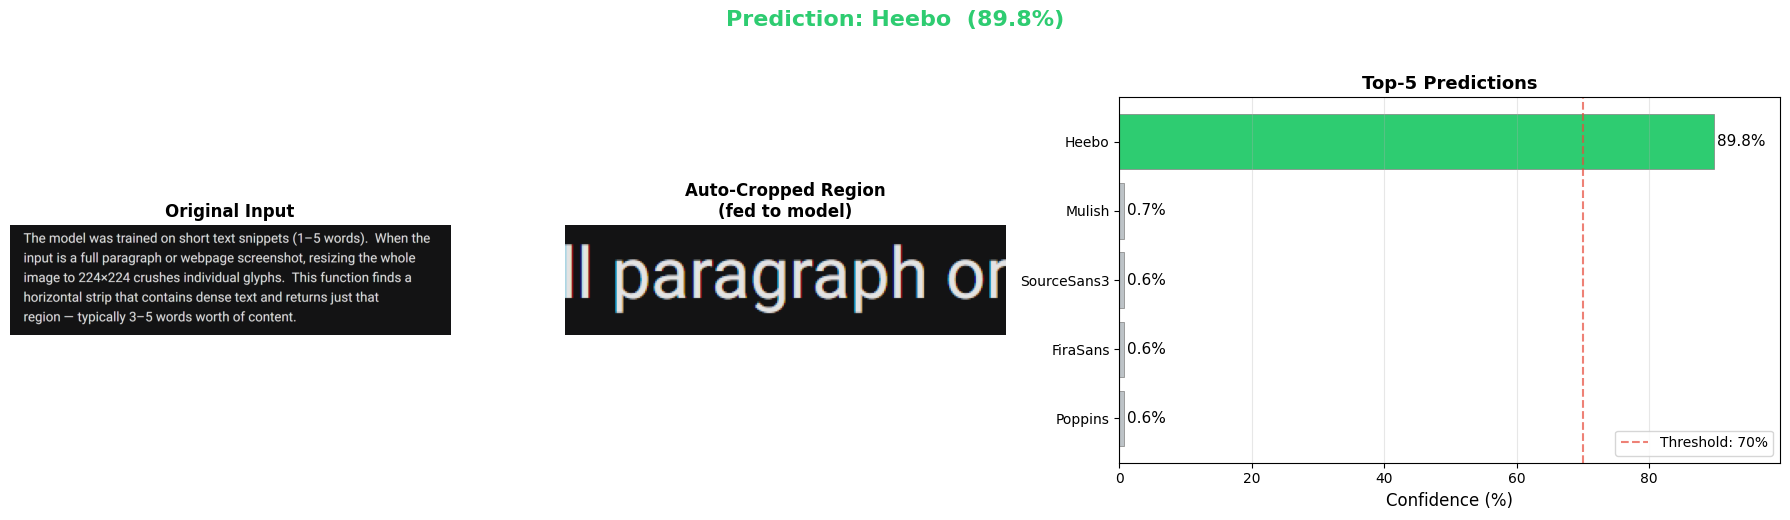

  ✓ Predicted font : Heebo
    Confidence     : 89.8%
    Auto-cropped   : 1398×350 → 264×66

Top-5 predictions:
  → 1. Heebo            89.8%
    2. Mulish            0.7%
    3. SourceSans3       0.6%
    4. FiraSans          0.6%
    5. Poppins           0.6%


In [6]:
# Predict
TEST_IMAGE = "../test_images/image.png"

result = predict_font(TEST_IMAGE)

# Check if a crop was actually applied
was_cropped = (result["image"].size != result["cropped"].size)

# Layout: 3 columns if cropped, 2 if not
if was_cropped:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5),
                             gridspec_kw={"width_ratios": [1, 1, 1.5]})
    ax_orig, ax_crop, ax_bar = axes

    # Original image
    ax_orig.imshow(result["image"])
    ax_orig.set_title("Original Input", fontsize=12, fontweight="bold")
    ax_orig.axis("off")

    # Cropped region
    ax_crop.imshow(result["cropped"])
    ax_crop.set_title("Auto-Cropped Region\n(fed to model)", fontsize=12, fontweight="bold")
    ax_crop.axis("off")
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5),
                             gridspec_kw={"width_ratios": [1, 1.5]})
    ax_img, ax_bar = axes

    ax_img.imshow(result["image"])
    ax_img.set_title("Input Image", fontsize=13, fontweight="bold")
    ax_img.axis("off")

# Top-5 confidence bar chart
fonts = [f for f, _ in result["top5"]]
confs = [c * 100 for _, c in result["top5"]]

colors = []
for f, c in result["top5"]:
    if f == result["top5"][0][0] and result["is_recognized"]:
        colors.append("#2ecc71")
    elif f == result["top5"][0][0] and not result["is_recognized"]:
        colors.append("#e74c3c")
    else:
        colors.append("#bdc3c7")

bars = ax_bar.barh(fonts[::-1], confs[::-1], color=colors[::-1], edgecolor="grey", linewidth=0.5)

for bar, conf in zip(bars, confs[::-1]):
    ax_bar.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
                f"{conf:.1f}%", va="center", fontsize=11)

ax_bar.axvline(CONFIDENCE_THRESHOLD * 100, color="#e74c3c", ls="--", alpha=0.7,
               label=f"Threshold: {CONFIDENCE_THRESHOLD:.0%}")
ax_bar.set_xlabel("Confidence (%)", fontsize=12)
ax_bar.set_xlim(0, max(confs) + 10)
ax_bar.legend(fontsize=10, loc="lower right")
ax_bar.set_title("Top-5 Predictions", fontsize=13, fontweight="bold")
ax_bar.grid(axis="x", alpha=0.3)

# Main title
status = result["predicted_font"]
conf_pct = result["confidence"] * 100
title_color = "#2ecc71" if result["is_recognized"] else "#e74c3c"
fig.suptitle(
    f"Prediction: {status}  ({conf_pct:.1f}%)",
    fontsize=16, fontweight="bold", color=title_color, y=1.03,
)

plt.tight_layout()
plt.show()

# Text summary
print("=" * 50)
if result["is_recognized"]:
    print(f"  ✓ Predicted font : {result['predicted_font']}")
    print(f"    Confidence     : {result['confidence']*100:.1f}%")
else:
    print(f"  ✗ Unrecognized font (confidence {result['confidence']*100:.1f}% < threshold {CONFIDENCE_THRESHOLD*100:.0f}%)")
    print(f"    Best guess     : {result['top5'][0][0]} — but below threshold")

if was_cropped:
    orig_w, orig_h = result["image"].size
    crop_w, crop_h = result["cropped"].size
    print(f"    Auto-cropped   : {orig_w}×{orig_h} → {crop_w}×{crop_h}")

print("=" * 50)
print("\nTop-5 predictions:")
for rank, (font, conf) in enumerate(result["top5"], 1):
    marker = "→" if rank == 1 else " "
    print(f"  {marker} {rank}. {font:<14s}  {conf*100:5.1f}%")